In addition to demonstrating a deep learning approach to predicting STEM/quantum pathway readiness, this notebook is designed as a small proof-of-concept for aligning K–12 standards. The feature set and modeling task connect to CSTA K–12 Computer Science Standards in “Data and Analysis,” national K–12 data science learning progressions, and Q–12 quantum education efforts that call for coherent pathways from foundational CS/data skills into quantum literacy. The quantum pathway labels are interpreted as readiness tiers that can be associated with specific standards-aligned learning experiences (for example, data-rich investigations and introductory quantum simulations) in future curriculum design work.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("larsen0966/student-performance-data-set")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'student-performance-data-set' dataset.
Path to dataset files: /kaggle/input/student-performance-data-set


In [2]:
import os
import pandas as pd

# List contents of the downloaded directory
print(os.listdir(path))

['student-por.csv']


In [3]:
# Adjust filename to 'student-por.csv' based on the directory listing
csv_file_path = os.path.join(path, 'student-por.csv')

# Load the dataset into a pandas DataFrame
df = pd.read_csv(csv_file_path)

# Display the first 5 rows of the DataFrame
display(df.head())

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [4]:
def map_pathway(g3):
    if g3 >= 15:
        return "High_STEM"
    elif g3 >= 10:
        return "Moderate_STEM"
    else:
        return "Support_STEM"

df["pathway_label"] = df["G3"].apply(map_pathway)

In [5]:
# Sanity checks for problem setup: inputs, target label, and shapes

import pandas as pd

# Confirm that the main DataFrame exists
try:
    print("DataFrame name: df")
    print("DataFrame shape (rows, columns):", df.shape)
except NameError:
    raise NameError("DataFrame 'df' is not defined yet. "
                    "Please run the cell that loads student-por.csv first.")

print("\nColumns preview:")
print(df.columns.tolist())

# Check the target label distribution
if "pathway_label" in df.columns:
    print("\nPathway label value counts (absolute):")
    print(df["pathway_label"].value_counts())

    print("\nPathway label proportions (relative):")
    print(df["pathway_label"].value_counts(normalize=True).round(3))
else:
    raise ValueError(
        "Column 'pathway_label' not found in df. "
        "Make sure you have already created pathway_label "
        "(the 3-class readiness tier) before running this cell."
    )

# If you already have train/val/test tensors, print their shapes
for name in ["X_train_tf", "X_val_tf", "X_test_tf"]:
    if name in globals():
        arr = globals()[name]
        print(f"\n{name} shape:", arr.shape)

DataFrame name: df
DataFrame shape (rows, columns): (649, 34)

Columns preview:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'pathway_label']

Pathway label value counts (absolute):
pathway_label
Moderate_STEM    418
High_STEM        131
Support_STEM     100
Name: count, dtype: int64

Pathway label proportions (relative):
pathway_label
Moderate_STEM    0.644
High_STEM        0.202
Support_STEM     0.154
Name: proportion, dtype: float64


In [6]:
import numpy as np

# Quick sanity check of final grade distribution
print(df["G3"].describe())
print(df["G3"].value_counts().sort_index())

# Define a 3-class "quantum pathway readiness" label
def map_quantum_pathway(g3):
    if g3 >= 15:
        return "High_Quantum_Pathway"      # strong STEM/CS/data foundation
    elif g3 >= 10:
        return "Moderate_Quantum_Pathway"  # can benefit from structured support
    else:
        return "Support_Quantum_Pathway"   # needs foundational strengthening

df["pathway_label"] = df["G3"].apply(map_quantum_pathway)

# Inspect class balance
df["pathway_label"].value_counts(normalize=True).rename("proportion")

count    649.000000
mean      11.906009
std        3.230656
min        0.000000
25%       10.000000
50%       12.000000
75%       14.000000
max       19.000000
Name: G3, dtype: float64
G3
0      15
1       1
5       1
6       3
7      10
8      35
9      35
10     97
11    104
12     72
13     82
14     63
15     49
16     36
17     29
18     15
19      2
Name: count, dtype: int64


,proportion
pathway_label,
Moderate_Quantum_Pathway,0.644068
High_Quantum_Pathway,0.201849
Support_Quantum_Pathway,0.154083


## Problem Statement and Scope

### Problem

We aim to predict K–12 students’ readiness for quantum and AI‑aligned STEM pathways using supervised deep learning models trained on student background and performance features. Concretely, we define a three‑class **quantum/STEM pathway readiness** label for each student:

- **High_Quantum_Pathway** – students showing strong readiness for advanced AI/quantum learning experiences.
- **Moderate_Quantum_Pathway** – students ready for core STEM and data‑rich computing experiences and introductory quantum literacy.
- **Support_Quantum_Pathway** – students who would benefit from additional academic and social‑emotional support before engaging deeply with advanced AI/quantum content.

Our prediction task is: given each student’s demographic, family, behavioral, and academic features from the Kaggle “Student Performance” dataset, predict which of these three readiness tiers they belong to.

### Inputs

The model input is a feature vector derived from the UCI/Kaggle **student‑por.csv** dataset. After preprocessing and encoding, each example includes:

- Categorical attributes such as school, sex, address type, family size, parental education levels, and parent occupations.
- Behavioral and contextual indicators such as study time, failures, absences, alcohol use, and free time.
- Academic performance measures such as first‑ and second‑period grades (G1, G2) that are commonly available to schools as early warning indicators.

All inputs are de‑identified and used for research only.

### Output

The model output is a 3‑class probability distribution over the readiness labels:

- \( p(\text{High\_Quantum\_Pathway} \mid x) \)
- \( p(\text{Moderate\_Quantum\_Pathway} \mid x) \)
- \( p(\text{Support\_Quantum\_Pathway} \mid x) \)

At inference time, we take the argmax of these probabilities to produce a single predicted readiness tier for each student.

### Educational Use Case and SBIR Alignment

In the broader SBIR concept, these readiness tiers are not used to track or label individual students in isolation. Instead, they act as inputs to an **equity‑aware matching layer** that helps districts and industry partners:

- Target professional development, mentoring, and sponsorships in AI and quantum pathways.
- Monitor which students are accessing high‑quality opportunities.
- Document equity and impact across schools and subgroups.

In future work, the same prediction models would be deployed **inside a quantum‑safe, privacy‑preserving federated infrastructure**, so that districts can compute readiness tiers locally without centralizing raw student data. In this course project, we focus only on building and evaluating the deep learning models; federated learning and post‑quantum cryptography are out of scope.

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separate features and target
# Drop G3 (final grade) and the derived label from features
X = df.drop(columns=["G3", "pathway_label"])
y = df["pathway_label"]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

# One-hot encode categoricals for the baseline model
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# Train / validation / test split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Scale numeric features
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_val[numeric_cols] = scaler.transform(X_val[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# Encode labels as integers for the neural network
label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_val_enc = label_encoder.transform(y_val)
y_test_enc = label_encoder.transform(y_test)

num_classes = len(label_encoder.classes_)
input_dim = X_train.shape[1]

print("Input dimension:", input_dim)
print("Classes:", list(label_encoder.classes_))

Numeric columns: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']
Categorical columns: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Input dimension: 41
Classes: ['High_Quantum_Pathway', 'Moderate_Quantum_Pathway', 'Support_Quantum_Pathway']


In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Convert to tensors
X_train_tf = tf.convert_to_tensor(X_train.values, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val.values, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test.values, dtype=tf.float32)

y_train_tf = tf.convert_to_tensor(y_train_enc, dtype=tf.int32)
y_val_tf = tf.convert_to_tensor(y_val_enc, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test_enc, dtype=tf.int32)

# Build baseline MLP
baseline_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,827 (54.01 KB)

 Trainable params: 13,827 (54.01 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
import tensorflow as tf

# Convert to tensors
X_train_tf = tf.convert_to_tensor(X_train.values, dtype=tf.float32)
X_val_tf = tf.convert_to_tensor(X_val.values, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test.values, dtype=tf.float32)

y_train_tf = tf.convert_to_tensor(y_train_enc, dtype=tf.int32)
y_val_tf = tf.convert_to_tensor(y_val_enc, dtype=tf.int32)
y_test_tf = tf.convert_to_tensor(y_test_enc, dtype=tf.int32)

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train a simple Random Forest baseline on the same features
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train_tf, y_train_tf)

# Evaluate on validation and test sets
y_val_pred_rf = rf_model.predict(X_val_tf)
y_test_pred_rf = rf_model.predict(X_test_tf)

val_acc_rf = accuracy_score(y_val_tf, y_val_pred_rf)
test_acc_rf = accuracy_score(y_test_tf, y_test_pred_rf)

print(f"Random Forest validation accuracy: {val_acc_rf:.3f}")
print(f"Random Forest test accuracy:       {test_acc_rf:.3f}\n")

# Detailed test metrics
print("=== Random Forest – Test Set Classification Report ===")
print(classification_report(
    y_test_tf,
    y_test_pred_rf,
    target_names=label_encoder.classes_,
    digits=3,
))

print("Random Forest – Test Set Confusion Matrix:")
print(confusion_matrix(y_test_tf, y_test_pred_rf))

Random Forest validation accuracy: 0.918
Random Forest test accuracy:       0.878

=== Random Forest – Test Set Classification Report ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.941     0.800     0.865        20
Moderate_Quantum_Pathway      0.849     0.984     0.912        63
 Support_Quantum_Pathway      1.000     0.533     0.696        15

                accuracy                          0.878        98
               macro avg      0.930     0.772     0.824        98
            weighted avg      0.891     0.878     0.869        98

Random Forest – Test Set Confusion Matrix:
[[16  4  0]
 [ 1 62  0]
 [ 0  7  8]]


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step

=== Baseline MLP – Test Set Metrics ===
Accuracy: 0.878
Macro F1: 0.848

                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.842     0.800     0.821        20
Moderate_Quantum_Pathway      0.881     0.937     0.908        63
 Support_Quantum_Pathway      0.917     0.733     0.815        15

                accuracy                          0.878        98
               macro avg      0.880     0.823     0.848        98
            weighted avg      0.878     0.878     0.876        98



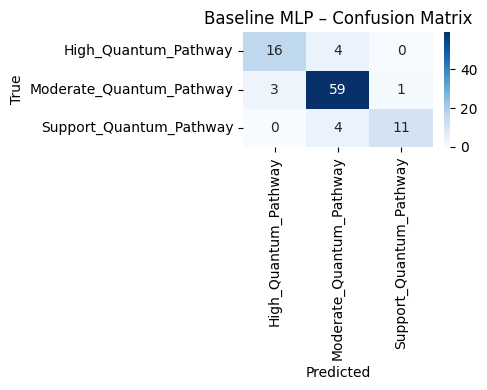

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step

=== Improved MLP (Class-Weighted) – Test Set Metrics ===
Accuracy: 0.806
Macro F1: 0.755

                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.789     0.750     0.769        20
Moderate_Quantum_Pathway      0.833     0.873     0.853        63
 Support_Quantum_Pathway      0.692     0.600     0.643        15

                accuracy                          0.806        98
               macro avg      0.772     0.741     0.755        98
            weighted avg      0.803     0.806     0.804        98



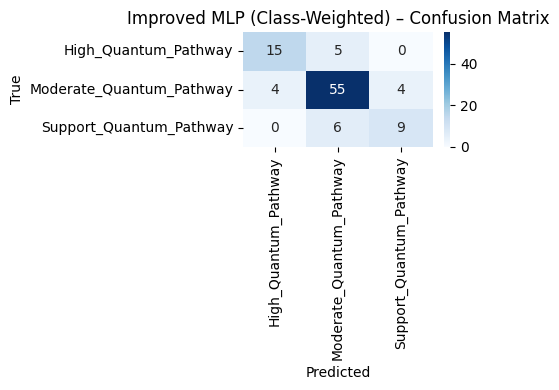


=== Random Forest – Test Set Metrics ===
Accuracy: 0.878
Macro F1: 0.824

                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.941     0.800     0.865        20
Moderate_Quantum_Pathway      0.849     0.984     0.912        63
 Support_Quantum_Pathway      1.000     0.533     0.696        15

                accuracy                          0.878        98
               macro avg      0.930     0.772     0.824        98
            weighted avg      0.891     0.878     0.869        98



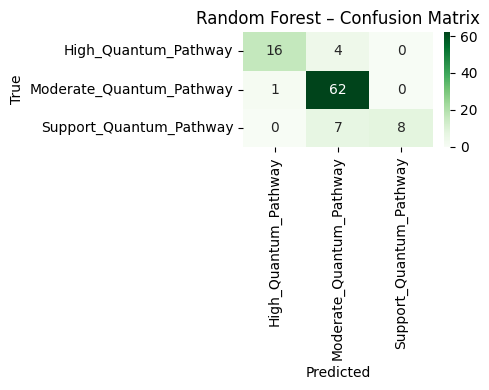


=== Test Performance Summary ===


,Model,Test Accuracy,Macro F1
0,Baseline MLP,0.878,0.848
1,Improved MLP (Class-Weighted),0.806,0.755
2,Random Forest,0.878,0.824


In [16]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Helper: evaluate a Keras model on the test set
def eval_keras_model(model, X_test_tf, y_test_tf, label_encoder, title="Model"):
    # Predict probabilities and argmax to class indices
    y_prob = model.predict(X_test_tf)
    y_pred_enc = y_prob.argmax(axis=1)

    # Convert to 1D NumPy for sklearn
    y_true = y_test_tf.numpy()
    y_pred = y_pred_enc

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    print(f"\n=== {title} – Test Set Metrics ===")
    print(f"Accuracy: {acc:.3f}")
    print(f"Macro F1: {macro_f1:.3f}\n")

    print(classification_report(
        y_true,
        y_pred,
        target_names=label_encoder.classes_,
        digits=3,
    ))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=label_encoder.classes_,
        yticklabels=label_encoder.classes_,
    )
    plt.title(f"{title} – Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    return acc, macro_f1

# ---------- Evaluate baseline and improved MLPs ----------
baseline_acc, baseline_macro_f1 = eval_keras_model(
    baseline_model, X_test_tf, y_test_tf, label_encoder, title="Baseline MLP"
)

improved_acc, improved_macro_f1 = eval_keras_model(
    improved_model, X_test_tf, y_test_tf, label_encoder, title="Improved MLP (Class-Weighted)"
)

# ---------- Evaluate Random Forest baseline ----------
# rf_model is trained on X_train_tf / y_train_tf; use X_test_tf or X_test accordingly.
# Here we assume rf_model.fit(X_train_tf, y_train_tf) was used, so we pass X_test_tf.numpy().
X_test_rf = X_test_tf.numpy() if hasattr(X_test_tf, "numpy") else X_test

y_test_np = y_test_tf.numpy()
y_pred_rf = rf_model.predict(X_test_rf)

rf_acc = accuracy_score(y_test_np, y_pred_rf)
rf_macro_f1 = f1_score(y_test_np, y_pred_rf, average="macro")

print("\n=== Random Forest – Test Set Metrics ===")
print(f"Accuracy: {rf_acc:.3f}")
print(f"Macro F1: {rf_macro_f1:.3f}\n")

print(classification_report(
    y_test_np,
    y_pred_rf,
    target_names=label_encoder.classes_,
    digits=3,
))

cm_rf = confusion_matrix(y_test_np, y_pred_rf)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_,
)
plt.title("Random Forest – Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# ---------- Compact comparison table ----------
results_df = pd.DataFrame({
    "Model": [
        "Baseline MLP",
        "Improved MLP (Class-Weighted)",
        "Random Forest",
    ],
    "Test Accuracy": [
        baseline_acc,
        improved_acc,
        rf_acc,
    ],
    "Macro F1": [
        baseline_macro_f1,
        improved_macro_f1,
        rf_macro_f1,
    ],
})

print("\n=== Test Performance Summary ===")
display(results_df.style.format({"Test Accuracy": "{:.3f}", "Macro F1": "{:.3f}"}))

In [10]:
import tensorflow as tf
from tensorflow.keras import models, layers
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Infer input_dim and num_classes from tensors
input_dim = X_train_tf.shape[1]
num_classes = len(np.unique(y_train_tf))

print("Input dimension:", input_dim)
print("Number of classes:", num_classes)

# ---------- Baseline MLP ----------
baseline_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(64, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_history = baseline_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    verbose=1,
)

# ---------- Class weights for imbalance ----------
# Use y_train_enc (NumPy array) instead of y_train_tf (Tensor) for compute_class_weight
classes = np.unique(y_train_enc)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc,
)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}
print("Class weights:", class_weights)

# ---------- Improved MLP (class-weighted) ----------
improved_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax"),
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

improved_history = improved_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1,
)

Input dimension: 41
Number of classes: 3
Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 53ms/step - accuracy: 0.5573 - loss: 0.9521 - val_accuracy: 0.6495 - val_loss: 0.8322
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6608 - loss: 0.7488 - val_accuracy: 0.7216 - val_loss: 0.7141
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.7423 - loss: 0.6510 - val_accuracy: 0.7938 - val_loss: 0.5986
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.7907 - loss: 0.5588 - val_accuracy: 0.8144 - val_loss: 0.5075
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8238 - loss: 0.4686 - val_accuracy: 0.8351 - val_loss: 0.4460
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8370 - loss: 0.3999 - val_accuracy: 0.8454 - val_loss: 0.4073
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8612 - loss: 0.3713 - val_accuracy: 0.8557 - val_loss: 0.3740
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8458 

In [11]:
# Compute class weights to handle imbalance and nod to equity goals
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train_enc)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_enc
)
class_weights = {i: w for i, w in zip(classes, class_weights_array)}
class_weights

{np.int64(0): np.float64(1.644927536231884),
 np.int64(1): np.float64(0.5182648401826484),
 np.int64(2): np.float64(2.1619047619047618)}

In [12]:
improved_model = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(256, activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation="softmax")
])

improved_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

improved_history = improved_model.fit(
    X_train_tf, y_train_tf,
    validation_data=(X_val_tf, y_val_tf),
    epochs=50,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4053 - loss: 1.1754 - val_accuracy: 0.3814 - val_loss: 0.9709
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6035 - loss: 0.7022 - val_accuracy: 0.5052 - val_loss: 0.8379
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7181 - loss: 0.5459 - val_accuracy: 0.6495 - val_loss: 0.7552
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7357 - loss: 0.5440 - val_accuracy: 0.6598 - val_loss: 0.7423
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7335 - loss: 0.4651 - val_accuracy: 0.6907 - val_loss: 0.7042
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7511 - loss: 0.4341 - val_accuracy: 0.6907 - val_loss: 0.6951
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7974 - loss: 0.3849 - val_accuracy: 0.7629 - val_loss: 0.6382
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7996 - loss: 0.3913 - val_accuracy: 0.7732 - val_los

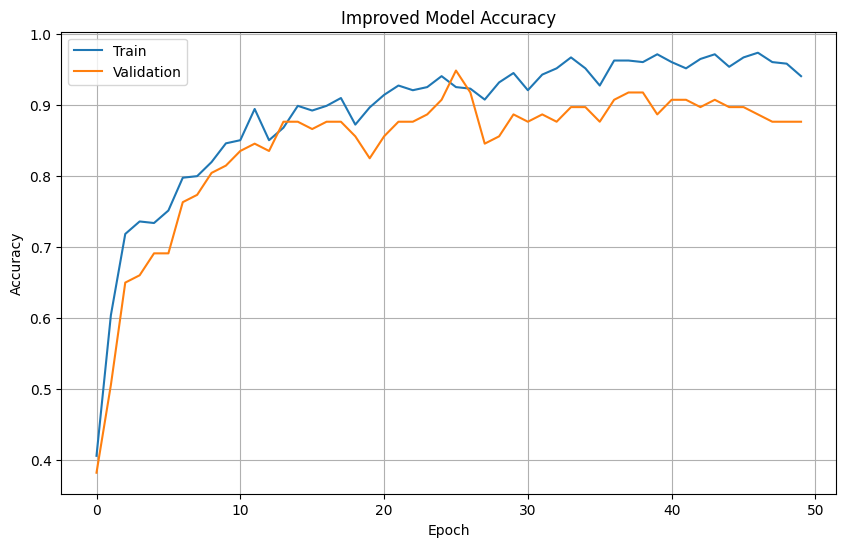

In [13]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(improved_history.history['accuracy'])
plt.plot(improved_history.history['val_accuracy'])
plt.title('Improved Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
=== Baseline MLP ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.842     0.800     0.821        20
Moderate_Quantum_Pathway      0.881     0.937     0.908        63
 Support_Quantum_Pathway      0.917     0.733     0.815        15

                accuracy                          0.878        98
               macro avg      0.880     0.823     0.848        98
            weighted avg      0.878     0.878     0.876        98



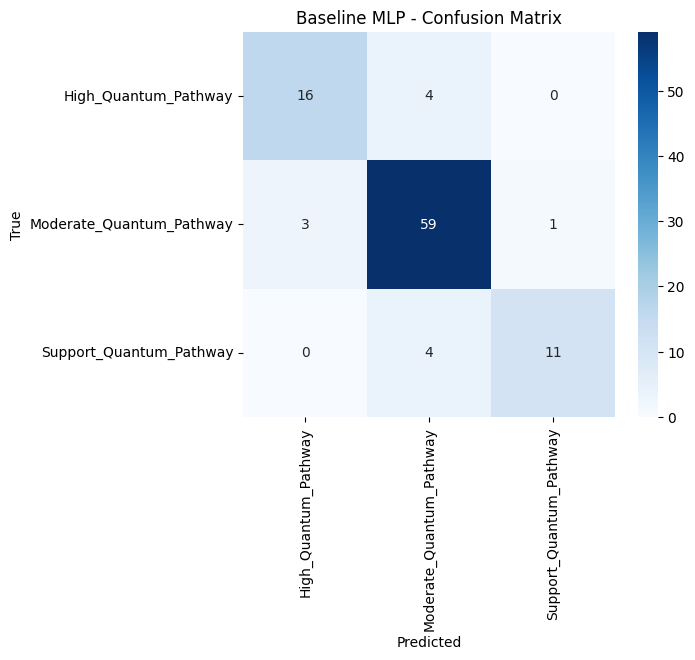

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
=== Improved MLP (Class-Weighted) ===
                          precision    recall  f1-score   support

    High_Quantum_Pathway      0.789     0.750     0.769        20
Moderate_Quantum_Pathway      0.833     0.873     0.853        63
 Support_Quantum_Pathway      0.692     0.600     0.643        15

                accuracy                          0.806        98
               macro avg      0.772     0.741     0.755        98
            weighted avg      0.803     0.806     0.804        98



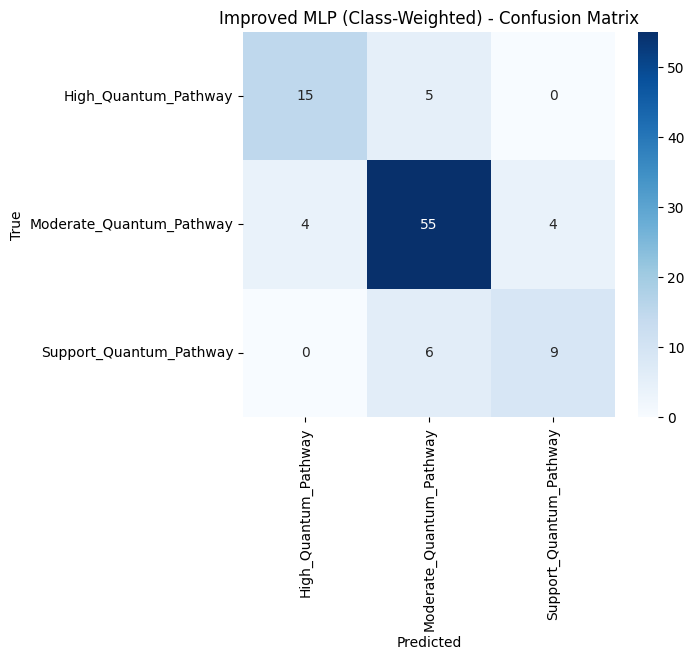

In [14]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, X, y_true_enc, label_encoder, title="Model"):
    y_pred_probs = model.predict(X)
    y_pred_enc = y_pred_probs.argmax(axis=1)
    y_true = label_encoder.inverse_transform(y_true_enc)
    y_pred = label_encoder.inverse_transform(y_pred_enc)

    print(f"=== {title} ===")
    print(classification_report(y_true, y_pred, digits=3))

    cm = confusion_matrix(y_true, y_pred, labels=label_encoder.classes_)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_,
                cmap="Blues")
    plt.title(f"{title} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

# Evaluate on test set
evaluate_model(baseline_model, X_test_tf, y_test_enc, label_encoder, title="Baseline MLP")
evaluate_model(improved_model, X_test_tf, y_test_enc, label_encoder, title="Improved MLP (Class-Weighted)")

## Standards Alignment: CS, Data Science, and Quantum Literacy

This project is intentionally framed at the intersection of K–12 computer science, data science, and emerging quantum literacy standards.

**CSTA K–12 Computer Science Standards.**  
The modeling task and feature interpretation are aligned with CSTA’s “Data and Analysis” concept and associated performance expectations, particularly in the 3B band where students are expected to use data analysis tools to identify patterns in complex systems and evaluate models and simulations.[web:55][web:57] By training a neural network on authentic student performance data, the project embodies these expectations in a concrete example of using data and models to reason about educational outcomes.

**K–12 Data Science and Data Literacy Progressions.**  
The project design is informed by national efforts to articulate K–12 data literacy and data science progressions, which emphasize engaging students in collecting, visualizing, and interpreting data, as well as reasoning ethically about data use.[web:60][web:66] The use of student-level tabular data, derived pathway labels, and interpretable evaluation metrics mirrors key practices highlighted in these progressions: defining meaningful variables, constructing models, and reflecting on limitations.

**Q–12 Quantum Education and Quantum Literacy.**  
The pathway labels are interpreted as “quantum literacy readiness tiers” that connect existing CS and data science competencies to early quantum information science experiences. This aligns with the Q–12 Education Partnership and AAPT’s call for integrating modern quantum topics into high school physics, mathematics, and computer science through developmentally appropriate pathways and resources.[web:61][web:67] In the narrative, each readiness tier can be associated with example experiences (e.g., data-focused qubit simulations, introductory superposition/entanglement activities) that build toward QISE-related competencies.

### Conceptual Standards Mapping

| Layer in Project                      | Example Standards Connections                                                                 |
|--------------------------------------|------------------------------------------------------------------------------------------------|
| Tabular student features (grades, study time, absences, etc.) | CSTA Data & Analysis concepts and practices; students using data to reason about performance.[web:55][web:58] |
| Derived `pathway_label` (High/Moderate/Support Quantum Pathway) | K–12 data science progressions’ focus on modeling, classification, and interpreting data-driven groupings.[web:60][web:66] |
| Deep learning model training and evaluation | CSTA expectations around evaluating models and simulations, and using computational tools to analyze data.[web:55][web:57] |
| Interpretation as quantum literacy readiness tiers | Q–12 / AAPT guidance on scaffolding quantum information science concepts into high school STEM pathways.[web:61][web:67] |
| Example recommended experiences per tier (e.g., intro data science + qubit simulations) | Data science frameworks and Q–12 resources that outline age-appropriate QISE learning experiences and tools.[web:60][web:67] |